# 06 · Scaling sensitivity

This notebook isolates the scaling issue that affects layer-wise SAE prediction, especially Natural Stories L01. It is meant for presentation: one graph shows the gain across layers, and a second panel shows how the SD-floor correction changes the unstable L01 comparison.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "results").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import *

P = paths(ROOT)
FIG = P["figures"]
set_style()
pd.set_option("display.precision", 3)

## What “scaling sensitivity” means here

The SAE regression uses sparse feature activations as predictors. Most sparse features are well behaved, but an extremely rare feature can have a tiny training standard deviation. If that rare feature receives a large coefficient, one held-out token can produce an extreme prediction.

This matters most for **Natural Stories L01**. The original L01 result is not a meaningful negative layer effect; it is a scaling failure driven by a rare sparse feature. The SD-floor check asks: what happens if we prevent very small training standard deviations from producing unstable feature scaling?

In [2]:
model_cmp = pd.read_csv(ROOT / "reports/sae_prediction/model_comparison.csv")
scaling = pd.read_csv(ROOT / "reports/scaling_sensitivity/comparison.csv")

sae_layers = (model_cmp[(model_cmp.representation == "sae") & (model_cmp.label != "inner_selected")]
              .copy())
for col in ["delta_r2", "ci_low", "ci_high"]:
    sae_layers[col + "_pp"] = 100 * sae_layers[col]
sae_layers["layer_idx"] = sae_layers.label.map({h: i for i, h in enumerate(HOOK_ORDER)})

scaling_display = scaling.copy()
scaling_display["Dataset"] = scaling_display.corpus.map(lambda c: CORPUS_LABELS[c].split(" ·")[0])
scaling_display["State"] = scaling_display.state.map(STATE_LABELS)
display(scaling_display[["Dataset", "State", "hook", "original_gain_pp", "floor_gain_pp",
                         "floor_ci_low_pp", "floor_ci_high_pp", "original_max_abs_error",
                         "floor_max_abs_error", "texts_improved", "n_texts"]].round(2))

,Dataset,State,hook,original_gain_pp,floor_gain_pp,floor_ci_low_pp,floor_ci_high_pp,original_max_abs_error,floor_max_abs_error,texts_improved,n_texts
0,Provo,Before word,L01,2.87,3.41,2.53,4.33,0.40,0.40,44,55
1,Provo,After word,L01,6.58,6.53,5.28,7.82,0.41,0.40,48,55
2,Natural Stories,Before word,L01,-3521.03,0.62,0.20,0.95,69.47,1.07,9,10
3,Natural Stories,After word,L01,-9131.48,2.13,1.47,2.81,111.88,1.10,10,10


## Layer-wise gain with off-scale failures marked

The plot clips the y-axis so useful layer differences remain visible. Any point below the lower boundary is marked at the bottom with “off scale.” The corrected L01 point from the scaling-sensitivity check is shown as a filled star.

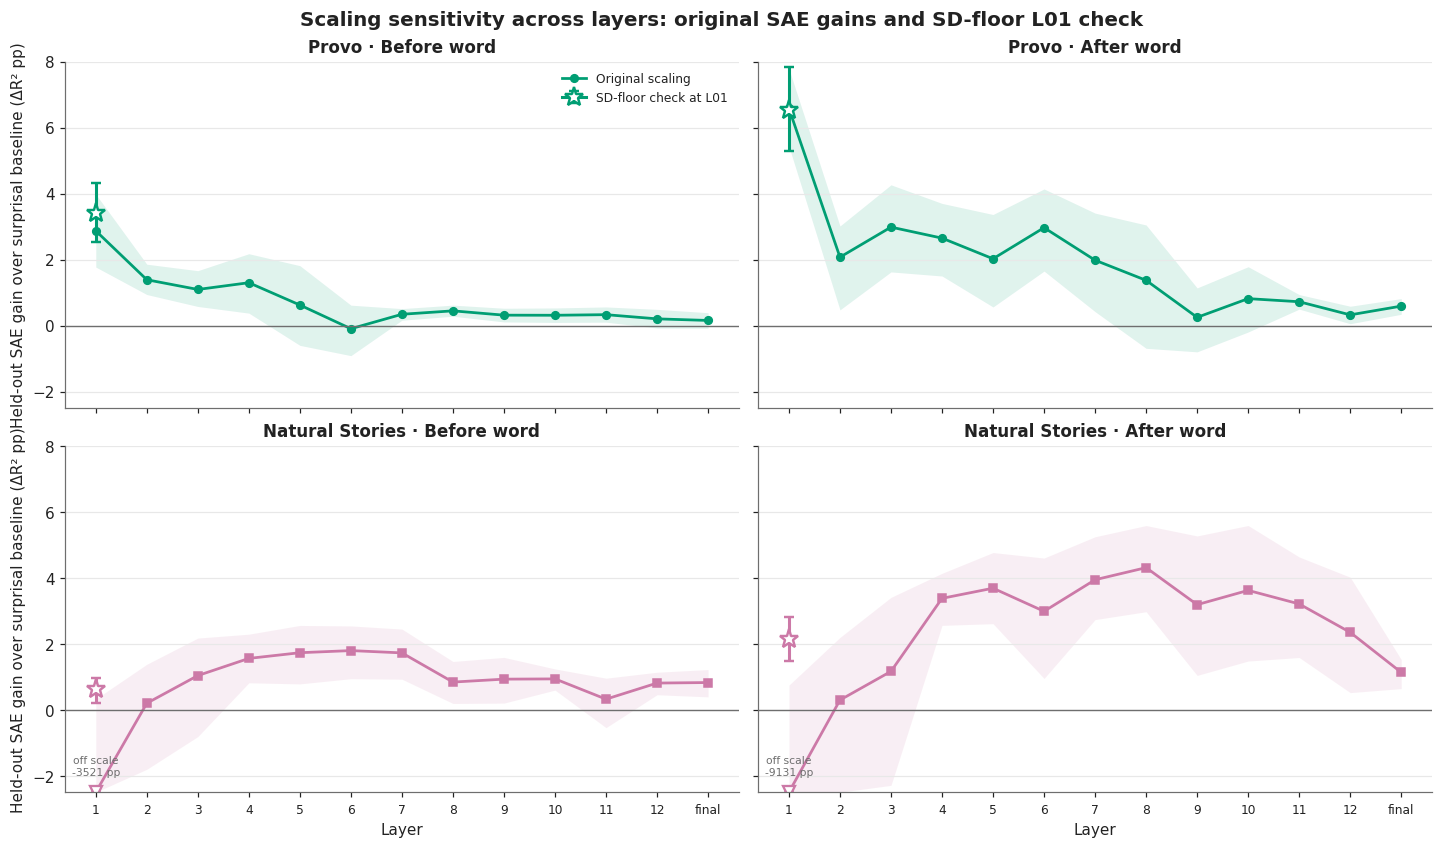

In [3]:
clip = (-2.5, 8.0)
x = np.arange(len(HOOK_ORDER))
fig, axes = plt.subplots(2, 2, figsize=(13, 7.6), layout="constrained", sharex=True, sharey=True)

for row, corpus in enumerate(CORPORA):
    for col, kind in enumerate(["prefix", "post"]):
        ax = axes[row, col]
        g = sae_layers[(sae_layers.corpus == corpus) & (sae_layers.kind == kind)].set_index("label").reindex(HOOK_ORDER)
        color = CORPUS_COLORS[corpus]
        y = g.delta_r2_pp.to_numpy(float)
        lo = g.ci_low_pp.to_numpy(float)
        hi = g.ci_high_pp.to_numpy(float)
        y_plot = np.clip(y, *clip)
        lo_plot = np.clip(lo, *clip)
        hi_plot = np.clip(hi, *clip)
        ax.fill_between(x, lo_plot, hi_plot, color=color, alpha=0.12, lw=0)
        ax.plot(x, y_plot, color=color, marker=CORPUS_MARKERS[corpus], mfc=color, ms=5, lw=1.8, label="Original scaling")
        off = y < clip[0]
        for xi, yi in zip(x[off], y[off]):
            ax.plot(xi, clip[0], marker="v", color=color, mfc="white", ms=8, mew=1.5)
            ax.annotate(f"off scale\n{yi:.0f} pp", (xi, clip[0]), xytext=(0, 10), textcoords="offset points",
                        ha="center", va="bottom", fontsize=7, color=MUTED)

        srow = scaling[(scaling.corpus == corpus) & (scaling.state == kind)]
        if not srow.empty:
            r = srow.iloc[0]
            sx = HOOK_ORDER.index(r.hook)
            ax.errorbar(sx, r.floor_gain_pp, yerr=[[r.floor_gain_pp - r.floor_ci_low_pp], [r.floor_ci_high_pp - r.floor_gain_pp]],
                        marker="*", color=color, mfc="white", mec=color, mew=1.6, ms=13, lw=2.0, capsize=3,
                        label="SD-floor check at L01")

        ax.axhline(0, color=MUTED, lw=0.9)
        ax.grid(axis="y", color=GRID)
        ax.set_ylim(*clip)
        ax.set_title(f"{CORPUS_LABELS[corpus].split(' ·')[0]} · {STATE_LABELS[kind]}")
        if row == 1:
            ax.set_xticks(x, HOOK_TICKS, fontsize=8)
            ax.set_xlabel("Layer")
        if col == 0:
            ax.set_ylabel("Held-out SAE gain over surprisal baseline (ΔR² pp)")
        if row == 0 and col == 0:
            ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Scaling sensitivity across layers: original SAE gains and SD-floor L01 check", fontsize=13, fontweight="bold")
save_figure(fig, FIG, "06_scaling_sensitivity_layer_gains")
plt.show()

## How to explain this slide

- **Provo:** L01 stays strong under the scaling check. The result is not an artifact of an extreme prediction.
- **Natural Stories:** original L01 is off scale and should not be interpreted as a real negative layer. The SD-floor check turns it into a small positive result.
- **Natural Stories L08:** the selected mid-layer result is separate from the L01 scaling failure. L08 remains the main interpretation target because it is selected most often by inner cross-validation and does not show the same extreme-error pattern.

The takeaway for the presentation is simple: scaling sensitivity affects the unstable Natural Stories L01 runs, but it does not explain away the main Provo L01 finding or the Natural Stories L08 layer-selection story.

In [4]:
table = scaling_display[["Dataset", "State", "hook", "original_gain_pp", "floor_gain_pp",
                         "floor_ci_low_pp", "floor_ci_high_pp", "floor_minus_original_pp",
                         "original_max_abs_error", "floor_max_abs_error"]].copy()
table.columns = ["Dataset", "State", "Hook", "Original gain (pp)", "SD-floor gain (pp)",
                 "SD-floor CI low", "SD-floor CI high", "Floor − original",
                 "Original max |error|", "SD-floor max |error|"]
display(focus_table(table.round(2), important=["SD-floor gain (pp)"],
                    signed_columns=["Original gain (pp)", "SD-floor gain (pp)", "Floor − original"],
                    caption="Scaling sensitivity summary. Large Natural Stories changes indicate an unstable original L01 scaling, not a meaningful negative layer effect."))

Dataset,State,Hook,Original gain (pp),SD-floor gain (pp),SD-floor CI low,SD-floor CI high,Floor − original,Original max |error|,SD-floor max |error|
Provo,Before word,L01,2.870000,3.410000,2.530000,4.330000,0.540000,0.400000,0.400000
Provo,After word,L01,6.580000,6.530000,5.280000,7.820000,-0.050000,0.410000,0.400000
Natural Stories,Before word,L01,-3521.030000,0.620000,0.200000,0.950000,3521.650000,69.470000,1.070000
Natural Stories,After word,L01,-9131.480000,2.130000,1.470000,2.810000,9133.610000,111.880000,1.100000
